# Trabalho 4 - MO443

1s/2026

Prof. Hélio Pedrini

Luís Antônio Almeida Lima Vieira
RA: 221045

In [ ]:
import os
from geometric_transforms import apply_transform
import cv2
import glob
import matplotlib.pyplot as plt
import numpy as np

## Transformações Geométricas

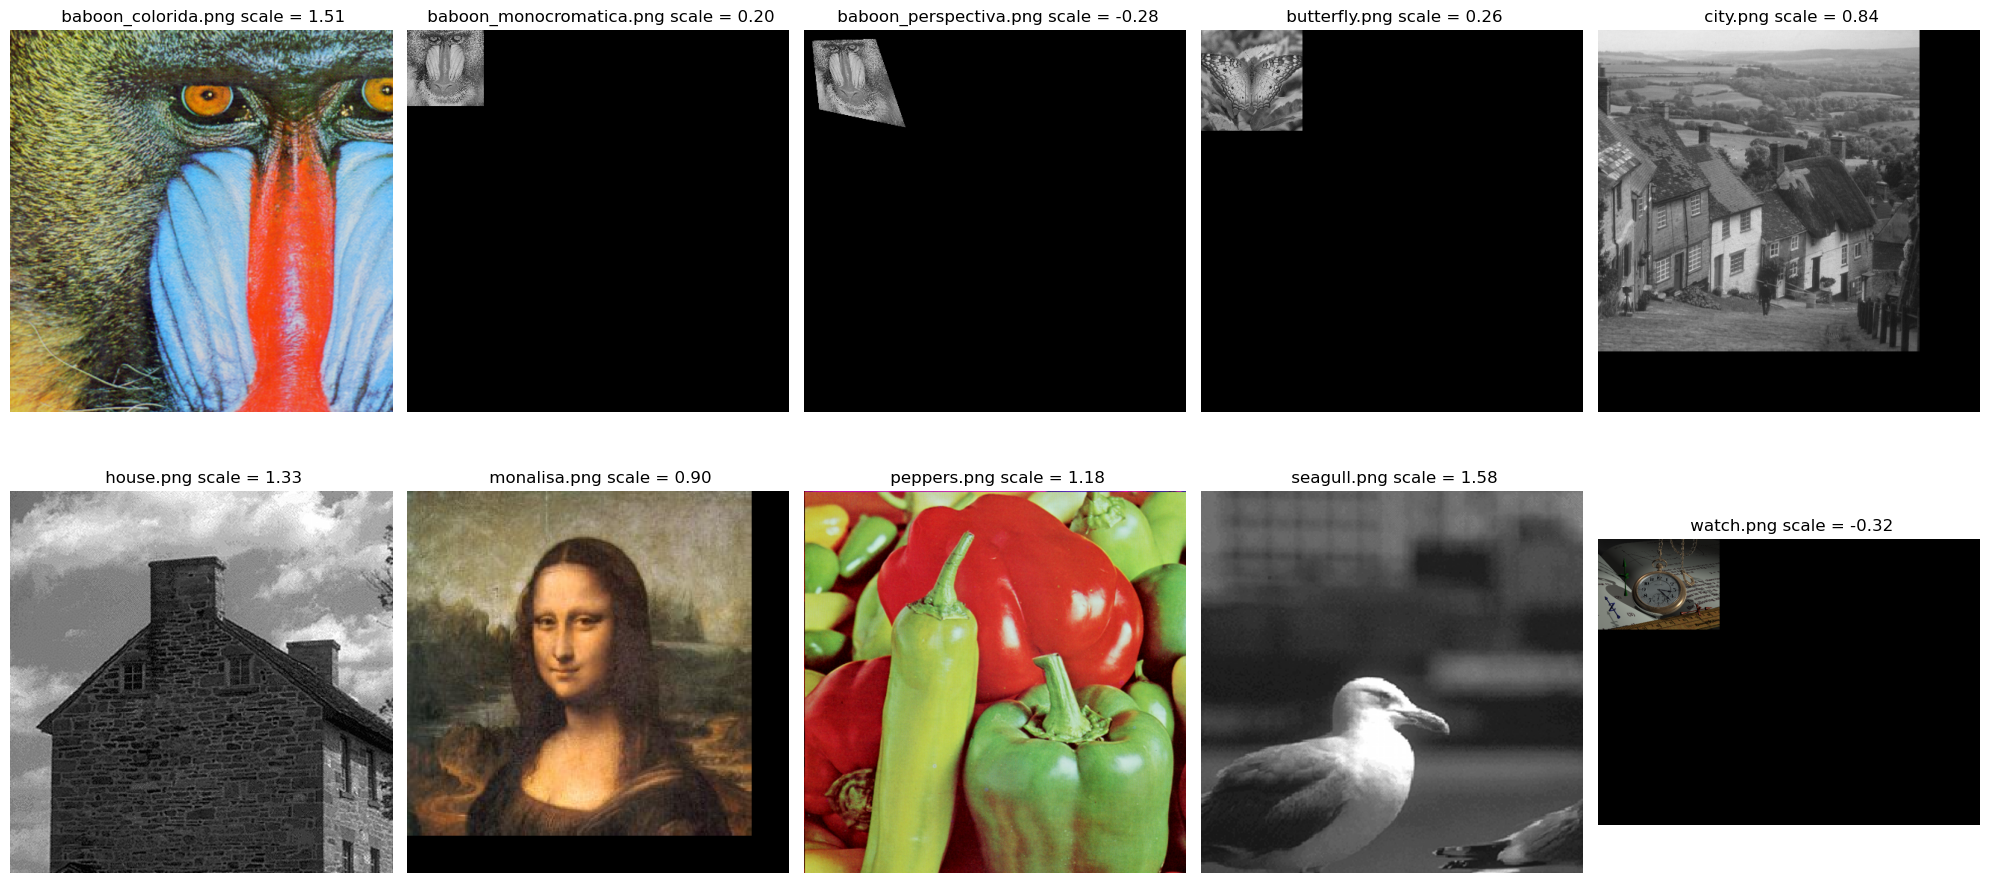

In [ ]:
fig, axs = plt.subplots(2, 5, figsize=(20,10))
axs = axs.flatten()

for ax, path in zip(axs, glob.glob('./images/*.png')):

    img = cv2.imread(path)

    scale_factor = np.random.uniform(-0.5, 2.6)

    img_transf = apply_transform(
        img,
        interpolation='lagrange',
        output_size=None,
        scale_factor=scale_factor,
        rotate_angle=None
    )

    ax.imshow(cv2.cvtColor(img_transf, cv2.COLOR_BGR2RGB))
    ax.set_title(f" {os.path.basename(path)} scale = {scale_factor:.2f}")
    ax.axis("off")

plt.tight_layout()
plt.savefig('./outputs/geometric_transforms/scale_transforms.png')
plt.show()

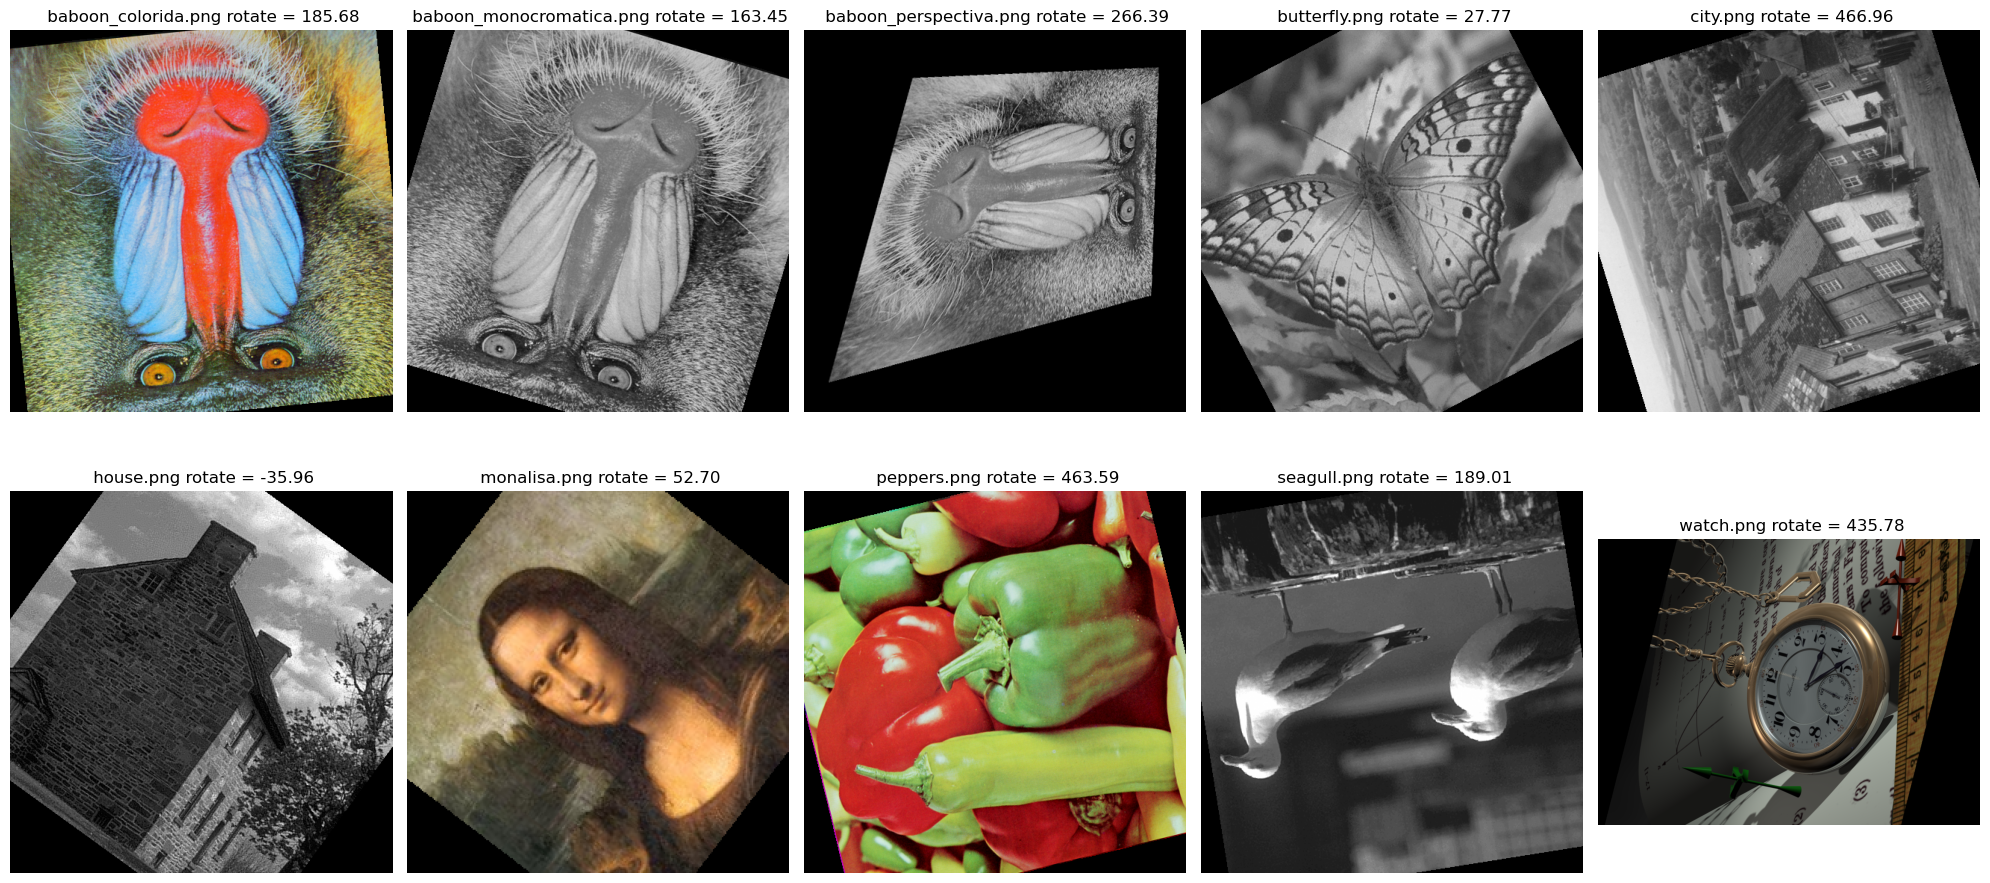

In [ ]:
fig, axs = plt.subplots(2, 5, figsize=(20,10))
axs = axs.flatten()

for ax, path in zip(axs, glob.glob('./images/*.png')):

    img = cv2.imread(path)

    rotate_factor = np.random.uniform(-90.5, 486.9)

    img_transf = apply_transform(
        img,
        interpolation='lagrange',
        output_size=None,
        scale_factor=None,
        rotate_angle=rotate_factor
    )

    ax.imshow(cv2.cvtColor(img_transf, cv2.COLOR_BGR2RGB))
    ax.set_title(f" {os.path.basename(path)} rotate = {rotate_factor:.2f}")
    ax.axis("off")

plt.tight_layout()
plt.savefig('./outputs/geometric_transforms/rotate_transforms.png')
plt.show()

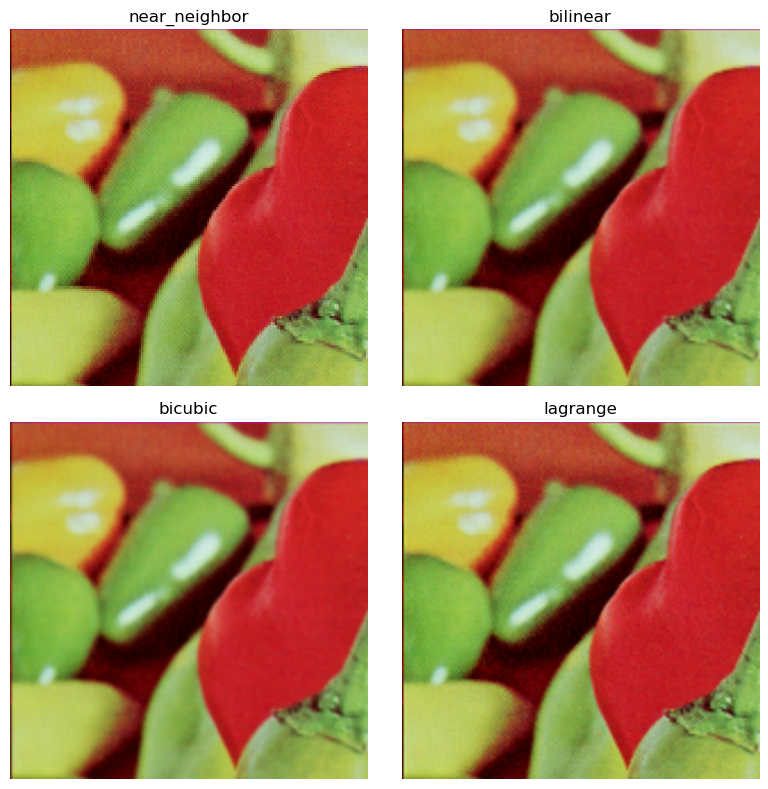

In [ ]:
fig, axs = plt.subplots(2, 2, figsize=(8,8))
axs = axs.flatten()


for ax, method in zip(axs, ['near_neighbor', 'bilinear','bicubic', 'lagrange']):

    img = cv2.imread('./images/peppers.png')

    img_transf = apply_transform(
        img,
        interpolation=method,
        output_size=None,
        scale_factor=3.25,
        rotate_angle=None
    )


    ax.imshow(cv2.cvtColor(img_transf, cv2.COLOR_BGR2RGB))
    ax.set_title(method)
    ax.axis("off")

plt.tight_layout()
plt.savefig('./outputs/geometric_transforms/interpolation_methods_scale.png')
plt.show()

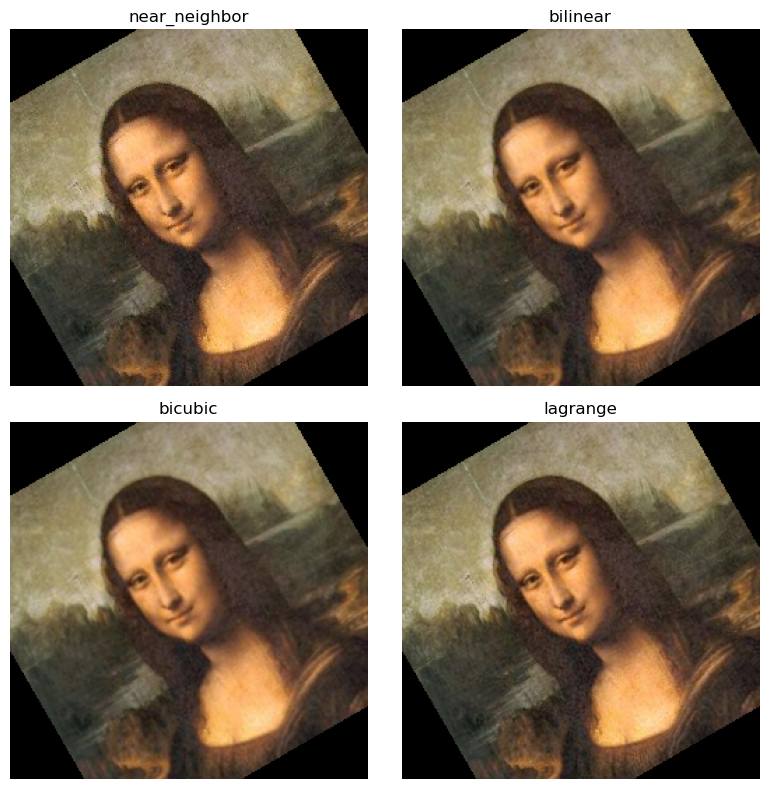

In [ ]:
fig, axs = plt.subplots(2, 2, figsize=(8,8))
axs = axs.flatten()


for ax, method in zip(axs, ['near_neighbor', 'bilinear','bicubic', 'lagrange']):

    img = cv2.imread('./images/monalisa.png')

    img_transf = apply_transform(
        img,
        interpolation=method,
        output_size=None,
        scale_factor=None,
        rotate_angle=30
    )

    ax.imshow(cv2.cvtColor(img_transf, cv2.COLOR_BGR2RGB))
    ax.set_title(method)
    ax.axis("off")

plt.tight_layout()
plt.savefig('./outputs/geometric_transforms/interpolation_methods_rotate.png')
plt.show()

## Registro

- Plots para cada imagem

Foram encontrados 4238 pontos de interesse
Foram encontrados 5341 pontos de interesse
Matriz de homografia
[[ 7.65083600e-01  3.77745649e-02  4.46582266e+02]
 [-1.35818040e-01  9.12231370e-01  7.61104944e+01]
 [-2.11943857e-04 -3.15416127e-05  1.00000000e+00]]


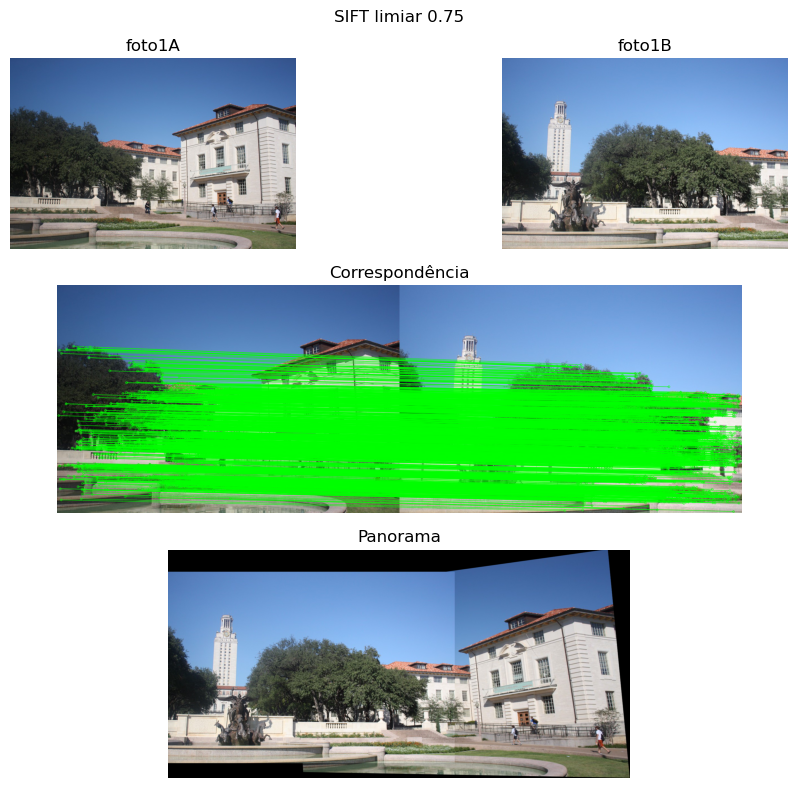

Foram encontrados 500 pontos de interesse
Foram encontrados 500 pontos de interesse
Matriz de homografia
[[ 8.08712106e-01  1.06903719e-01  4.28069460e+02]
 [-1.33209727e-01  9.91404765e-01  5.66224542e+01]
 [-2.08056348e-04  4.38315181e-05  1.00000000e+00]]


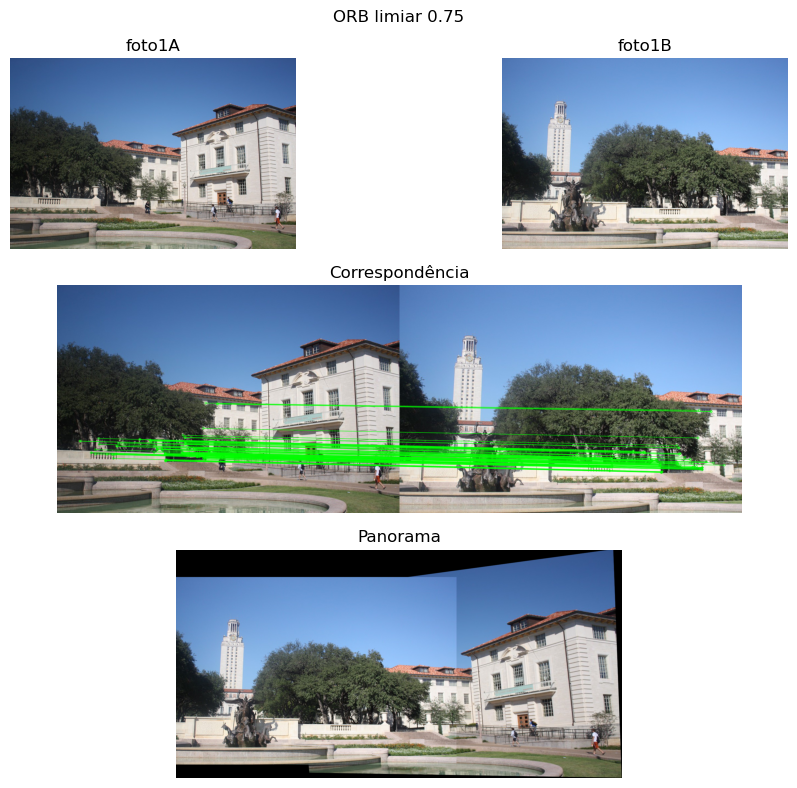

Foram encontrados 12962 pontos de interesse
Foram encontrados 15524 pontos de interesse
Matriz de homografia
[[ 7.77098873e-01  4.05872059e-02  4.46163292e+02]
 [-1.33141691e-01  9.20492509e-01  7.44981042e+01]
 [-2.03329522e-04 -2.42996234e-05  1.00000000e+00]]


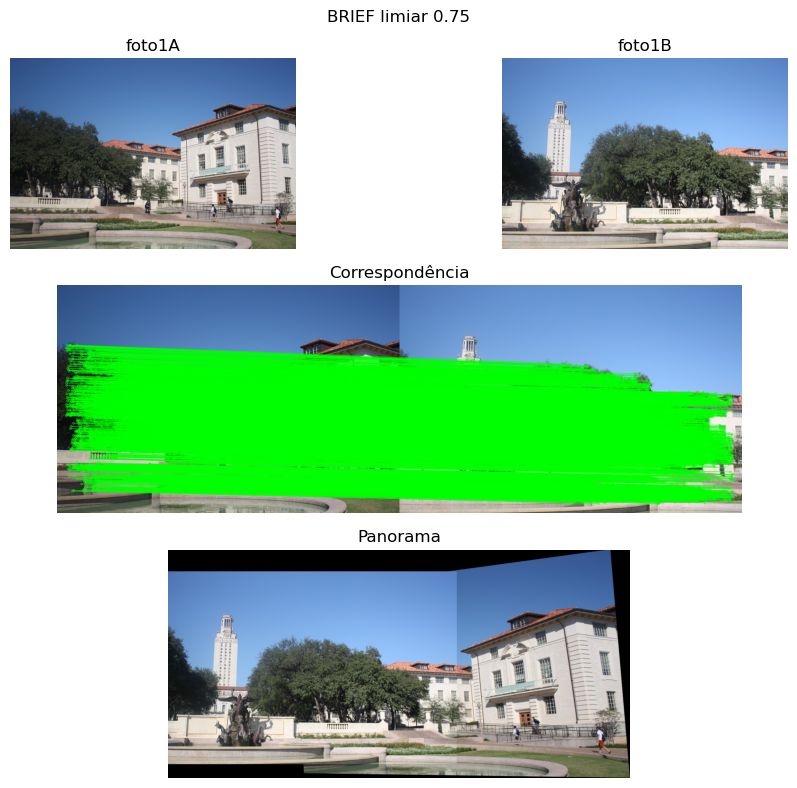

In [3]:
from register import registry
import matplotlib.pyplot as plt
import glob
import os
import cv2

imgs_a = glob.glob(os.path.join('images', '*A.jpg'))
imgs_b = glob.glob(os.path.join('images', '*B.jpg'))

for img_a_p, img_b_p in zip(imgs_a, imgs_b):
    img_name = os.path.basename(img_a_p).split('.')[0] + '_' +  os.path.basename(img_b_p).split('.')[0]
    for descriptor in ["SIFT", "ORB", "BRIEF"]:
        img_a = cv2.imread(img_a_p)
        img_b = cv2.imread(img_b_p)
        panoram, cors = registry(
            img_a,
            img_b,
            limiar=0.75,
            descriptor=descriptor
        )
        fig = plt.figure(figsize=(10, 8))
        gs = fig.add_gridspec(
            3, 2,
            height_ratios=[1, 1.2, 1.2]
        )

        img_a_rgb = cv2.cvtColor(img_a, cv2.COLOR_BGR2RGB)
        img_b_rgb = cv2.cvtColor(img_b, cv2.COLOR_BGR2RGB)
        cors_rgb = cv2.cvtColor(cors, cv2.COLOR_BGR2RGB)
        panoram_rgb = cv2.cvtColor(panoram, cv2.COLOR_BGR2RGB)


        ax1 = fig.add_subplot(gs[0, 0])
        ax2 = fig.add_subplot(gs[0, 1])
        ax3 = fig.add_subplot(gs[1, :])
        ax4 = fig.add_subplot(gs[2, :])

        ax1.imshow(img_a_rgb)
        ax1.set_title(os.path.basename(img_a_p).split('.')[0])
        ax1.axis("off")

        ax2.imshow(img_b_rgb)
        ax2.set_title(os.path.basename(img_b_p).split('.')[0])
        ax2.axis("off")

        ax3.imshow(cors_rgb)
        ax3.set_title("Correspondência")
        ax3.axis("off")

        ax4.imshow(panoram_rgb)
        ax4.set_title("Panorama")
        ax4.axis("off")

        plt.suptitle(f"{descriptor} limiar {0.75}")

        plt.tight_layout()
        plt.savefig(f"outputs/register/comb_{img_name}_{descriptor}.jpg")
        plt.show()

    break


- Tempo de processamento das técnicas

In [ ]:
from register import get_processing_time

processing_times = get_processing_time(images_path = 'images')

processing_times

SIFT
images/foto1A.jpg images/foto1B.jpg
Foram encontrados 4238 pontos de interesse
Foram encontrados 5341 pontos de interesse
Matriz de homografia
[[ 7.65083600e-01  3.77745649e-02  4.46582266e+02]
 [-1.35818040e-01  9.12231370e-01  7.61104944e+01]
 [-2.11943857e-04 -3.15416127e-05  1.00000000e+00]]
processing time: 0.3172609806060791 s
-------------------------------
SIFT
images/foto2A.jpg images/foto2B.jpg
Foram encontrados 5446 pontos de interesse
Foram encontrados 5918 pontos de interesse
Matriz de homografia
[[ 9.99847410e-01 -3.69953346e-05  4.63007600e+02]
 [-1.31908150e-05  9.99944480e-01  5.53128741e-03]
 [-2.09960404e-07 -1.83930824e-08  1.00000000e+00]]
processing time: 0.3367748260498047 s
-------------------------------
SIFT
images/foto3A.jpg images/foto3B.jpg
Foram encontrados 1123 pontos de interesse
Foram encontrados 818 pontos de interesse
Matriz de homografia
[[ 9.88372127e-01 -1.97656822e-02  3.23899805e+01]
 [ 1.76239724e-02  9.82172659e-01 -1.29650787e+02]
 [ 1.88

{'SIFT': [0.3172609806060791,
  0.3367748260498047,
  0.09193587303161621,
  0.1461179256439209,
  0.09541058540344238],
 'ORB': [0.0863196849822998,
  0.07706212997436523,
  0.07976126670837402,
  0.06974387168884277,
  0.0666193962097168],
 'BRIEF': [0.5708279609680176,
  0.8126735687255859,
  0.1903386116027832,
  0.22268438339233398,
  0.10726141929626465]}

In [4]:
import numpy as np

for key, value in processing_times.items():
    print(f"{key}: {np.mean(value)} s")

SIFT: 0.19750003814697265 s
ORB: 0.07590126991271973 s
BRIEF: 0.38075718879699705 s
